# InSilicoICH: Part 3. Running Studies

This notebook combines the pieces from [01_phantoms.ipynb](01_phantoms.ipynb) and [02_scanners.ipynb](02_scanners.ipynb) into the full pipeline, checkout those notebooks for more in depth coverage of each

This notebook introduces the `ICHStudy` class, which is an extension of the VITools Study class used to run studies with the phantoms and scanners defined in the previous notebooks. ICHStudy is a subclass of the VITools Study class, which provides additional functionality for adding intracranial hemorrhage (ICH) phantoms, metadata and measurements to the study. It also includes methods for running the study and generating reports.

In [1]:
from insilicoICH.study import ICHStudy
ICHStudy?

/scratch/brandon.nelson/InSilicoICH/.ich/lib/python3.13/site-packages/monai/utils/module.py:399: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  pkg = __import__(module)  # top level module


Init signature:
ICHStudy(
    input_csv: pandas.core.frame.DataFrame | str | pathlib._local.Path | None = None,
)
Docstring:      Manages the generation and execution of in silico ICH virtual trials.
Init docstring:
Initializes a Study instance.

Args:
    input_csv (pd.DataFrame | str | Path | None, optional):
        Path to a CSV file or a pandas DataFrame containing study
        metadata. If None, an empty study is initialized.
        Defaults to None.
File:           /scratch/brandon.nelson/InSilicoICH/src/insilicoICH/study.py
Type:           type
Subclasses:     

In [2]:
ICHStudy.generate_from_distributions?

Signature:
ICHStudy.generate_from_distributions(
    phantoms: List[str],
    study_count: int = 1,
    subtype: List[Optional[str]] = [None, 'IPH', 'SDH', 'EDH'],
    fracture_length: List[int] = [0, 200],
    lesion_volume: Union[Dict, str, pathlib._local.Path] = None,
    lesion_attenuation: Union[Dict, str, pathlib._local.Path] = None,
    edema: List[int] = [0, 15],
    mass_effect: list[bool | float] = [0.1, 0.9],
    texture_contrast: List[float] = [0, 3],
    texture_scale: List[float] = [8, 64],
    complexity: List[int] = [1, 4],
    smoothness: List[float] = [0.1, 0.4],
    irregularity: List[float] = [0.1, 0.4],
    eccentricity: List[float] = [0.4, 0.8],
    add_augmentation: bool = True,
    **kwargs,
) -> pandas.core.frame.DataFrame
Docstring: Generates a DataFrame of study parameters by sampling from distributions.
File:      /scratch/brandon.nelson/InSilicoICH/src/insilicoICH/study.py
Type:      method

In [3]:
from VITools import get_available_phantoms
get_available_phantoms()

{'0.0 yr UNC Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.UNC_Head'>, age=0.0, phantom_dir=PosixPath('/projects01/didsr-aiml/common_data/pedsilicoich/UNC_Head_phantom')),
 '1.0 yr UNC Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.UNC_Head'>, age=1.0, phantom_dir=PosixPath('/projects01/didsr-aiml/common_data/pedsilicoich/UNC_Head_phantom')),
 '2.0 yr UNC Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.UNC_Head'>, age=2.0, phantom_dir=PosixPath('/projects01/didsr-aiml/common_data/pedsilicoich/UNC_Head_phantom')),
 '6.5 yr NIHPD Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.NIHPD_Head'>, age=6.5, phantom_dir=PosixPath('/projects01/didsr-aiml/common_data/pedsilicoich/NIHPD_Head_Phantom')),
 '9.0 yr NIHPD Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.NIHPD_Head'>, age=9.0, phantom_dir=PosixPath('/projects01/didsr-aiml/common_data/pedsilicoich/NIHPD_Head_Phantom')),
 '10.5 yr NIHPD He

In [4]:
lesion_volume = dict(IPH=[0.2, 10], SDH=[0.2, 10], EDH=[0.2, 10], Fracture=[0, 1]) # placeholders for fracture, eventually put in length, thickness etc
lesion_attn = dict(IPH=[40, 80], SDH=[40, 80], EDH=[40, 80], Fracture=[0, 1]) # placeholders for fracture, eventually put in length, thickness etc

In [5]:
import pandas as pd
from VITools import available_scanners

print(available_scanners)
study = ICHStudy()
study.metadata = pd.concat([
    study.metadata,
    ICHStudy.generate_from_distributions(get_available_phantoms(),
                            lesion_volume=lesion_volume,
                            lesion_attenuation=lesion_attn,
                            subtype=['EDH', 'SDH', 'IPH', 'Fracture'],
                            fracture_length=[150, 250],
                            views=[100],
                            scanner_model=['Siemens_DefinitionFlash'],
                            study_count=5,
                            seed=88)])
study.metadata

['GE_Lightspeed64', 'Scanner_Default', 'GE_Lightspeed16', 'Siemens_DefinitionFlash']


,case_id,phantom,scanner_model,kVp,mA,pitch,views,scan_coverage,recon_kernel,slice_thickness,...,texture_contrast,texture_scale,complexity,smoothness,irregularity,eccentricity,age,mass_effect,fracture_length,add_augmentation
0,case_0000,10.5 yr NIHPD Head,Siemens_DefinitionFlash,120.0,300.0,0.0,100.0,dynamic,soft,1,...,2.066607,45.096556,2.0,0.151849,0.194319,0.482457,10.5,0.148469,0,True
1,case_0001,2.0 yr UNC Head,Siemens_DefinitionFlash,120.0,300.0,0.0,100.0,dynamic,soft,1,...,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.588952,174,True
2,case_0002,38.0 yr MIDA Head,Siemens_DefinitionFlash,120.0,300.0,0.0,100.0,dynamic,soft,1,...,NaN,NaN,NaN,NaN,NaN,NaN,38.0,0.829402,157,True
3,case_0003,12.0 yr NIHPD Head,Siemens_DefinitionFlash,120.0,300.0,0.0,100.0,dynamic,soft,1,...,2.668390,8.303527,1.0,0.375013,0.154927,0.734912,12.0,0.332233,0,True
4,case_0004,11.5 yr NIHPD Head,Siemens_DefinitionFlash,120.0,300.0,0.0,100.0,dynamic,soft,1,...,2.955898,26.756408,3.0,0.199448,0.237354,0.454214,11.5,0.455610,0,True


In [6]:
study.metadata[['case_id', 'phantom', 'subtype', 'lesion_volume', 'lesion_attenuation']]

,case_id,phantom,subtype,lesion_volume,lesion_attenuation
0,case_0000,10.5 yr NIHPD Head,IPH,7.129293,67.474747
1,case_0001,2.0 yr UNC Head,EDH,3.763636,67.070707
2,case_0002,38.0 yr MIDA Head,EDH,8.614141,50.909091
3,case_0003,12.0 yr NIHPD Head,IPH,9.703030,52.525253
4,case_0004,11.5 yr NIHPD Head,IPH,5.941414,59.797980


In [7]:
study.metadata['case_seed']

0    688509
1    872779
2    688869
3    494585
4    662438
Name: case_seed, dtype: int64

In [8]:
study.run_all(parallel=False, overwrite=True)

  0%|          | 0/5 [00:00<?, ?it/s]

Now running: case 0
loading phantom: 10.5 yr NIHPD Head


pseudo-CT images not found; defaulting to otsu segmentation method
adding lesion to phantom: Lesion(type=IPH, volume_ml=7.16, coords_voxel=(159, 146, 75), seed=688509)
applying augmentations to phantom: <monai.transforms.spatial.array.RandAffine object at 0x14e774a8ef90>
Initializing Scanner object...
----------
* Calculating volume fraction maps for 4 materials and 189 slices...
* Writing volume fraction files for 4 materials and 189 slices, plus HU data...
* Writing /scratch/brandon.nelson/InSilicoICH/notebooks/results/case_0000/10.5 yr NIHPD Head/phantoms/0/0_ncat_adipose_197x233x189.raw...
* Writing /scratch/brandon.nelson/InSilicoICH/notebooks/results/case_0000/10.5 yr NIHPD Head/phantoms/0/0_ncat_water_197x233x189.raw...
* Writing /scratch/brandon.nelson/InSilicoICH/notebooks/results/case_0000/10.5 yr NIHPD Head/phantoms/0/0_ncat_brain_197x233x189.raw...
* Writing /scratch/brandon.nelson/InSilicoICH/notebooks/results/case_0000/10.5 yr NIHPD Head/phantoms/0/0_ncat_skull_197x233x18

in C> Preparing to allocate memory for material volume data...
in C> Allocated memory for image volume for material  1
in C> Copying data for material  1 into C memory...in C>  done.
in C> Allocated memory for image volume for material  2
in C> Copying data for material  2 into C memory...in C>  done.
in C> Allocated memory for image volume for material  3
in C> Copying data for material  3 into C memory...in C>  done.
in C> Allocated memory for image volume for material  4
in C> Copying data for material  4 into C memory...in C>  done.
in C> Allocated a total of    132 MB.


100%|██████████| 100/100 [02:05<00:00,  1.25s/it]


...

in C> Preparing to allocate memory for material volume data...
in C> Allocated memory for image volume for material  1
in C> Copying data for material  1 into C memory...in C>  done.
in C> Allocated memory for image volume for material  2
in C> Copying data for material  2 into C memory...in C>  done.
in C> Allocated a total of     66 MB.


100%|██████████| 100/100 [00:51<00:00,  1.93it/s]


Prep view
Applying LSC...done.

Applying Beam Hardening Correction (ACCURATE BHC)...Airscan
done.

Simulation is done.
fov size: 250
* Loading the projection data...
* Pre-weighting the filter...
* Applying the filter...
* Running the reconstruction...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
* Converting the recon results from a C array to a numpy array...
* Scaling recon data...
* Loading the projection data...
* Pre-weighting the filter...
* Applying the filter...
* Running the reconstruction...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
* Converting the recon results from a C array to a numpy array...
* Scaling recon data...
* Loading the projection data...
* Pre-weighting the filter...
* Applying the filter...
* Running the reconstruction...
* Converting projection data from a numpy array to a C array...
* Allocating a C ar

Scans completed in parallel:   0%|          | 0/5 [00:00<?, ?it/s]



Input metadata:

     case_id             phantom            scanner_model    kVp     mA  \
0  case_0000  10.5 yr NIHPD Head  Siemens_DefinitionFlash  120.0  300.0   
1  case_0001     2.0 yr UNC Head  Siemens_DefinitionFlash  120.0  300.0   
2  case_0002   38.0 yr MIDA Head  Siemens_DefinitionFlash  120.0  300.0   
3  case_0003  12.0 yr NIHPD Head  Siemens_DefinitionFlash  120.0  300.0   
4  case_0004  11.5 yr NIHPD Head  Siemens_DefinitionFlash  120.0  300.0   

   pitch  views scan_coverage recon_kernel  slice_thickness  ...  \
0    0.0  100.0       dynamic         soft                1  ...   
1    0.0  100.0       dynamic         soft                1  ...   
2    0.0  100.0       dynamic         soft                1  ...   
3    0.0  100.0       dynamic         soft                1  ...   
4    0.0  100.0       dynamic         soft                1  ...   

   texture_contrast  texture_scale  complexity  smoothness irregularity  \
0          2.066607      45.096556         2.0 

In [9]:
study.results['lesion'].unique()

array([nan, 'IPH', 'EDH', 'Fracture', 'EDH, Fracture'], dtype=object)

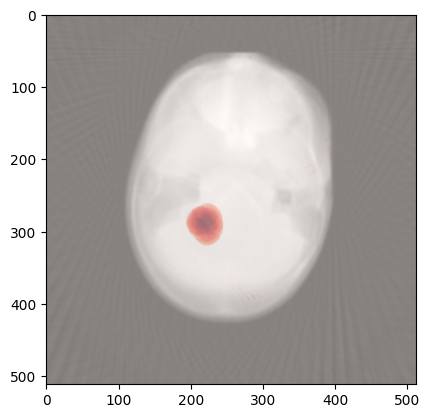

In [10]:
import matplotlib.pyplot as plt

idx = 0
mask = study.get_masks(idx)
imgs = study.get_images(idx)

plt.imshow(imgs.sum(axis=0), cmap='gray')
plt.imshow(mask.sum(axis=0), cmap='Reds', alpha=0.5)

In [11]:
from insilicoICH.lesion_definition import LesionFactory
phantom = get_available_phantoms()['10.5 yr NIHPD Head']()
lesion = LesionFactory().create('Fracture', boundary=phantom.get_skull_map(), spacings=phantom.spacings, seed=206245)
lesion.generate(fracture_length = 237)
phantom.insert_lesion(lesion)

pseudo-CT images not found; defaulting to otsu segmentation method
Starting random walk fracture generation with 237 iterations
Skull centroid at: (np.float64(99.85143784390517), np.float64(129.58702585312886), np.float64(110.48043141417469))
Casting rays with random walk...
Random walk ray casting complete!



        Phantom Class: NIHPD_Head
        Age (years): 10.5
        Shape (voxels): (189, 233, 197)
        Size (mm): (160.65, 198.05, 167.45)
        
Number of lesions: 1
  - Lesion 1: Fracture, Volume: 0.43 mL, Center: (34, 103, 76)
Mass effect strength: 0.0

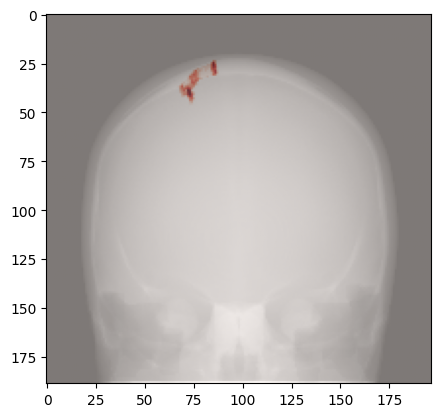

In [12]:
plt.imshow(phantom.get_CT_number_phantom().sum(axis=1), cmap='gray')
plt.imshow(phantom.lesions[0].mask.sum(axis=1), alpha=0.5, cmap='Reds')


**Fracture appears too high up, out of view, should add some preference for fractures at the sides, more hemorrhage risk and relevant**

In [13]:
%pip install -q matplotlib ipywidgets


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: /scratch/brandon.nelson/InSilicoICH/.ich/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


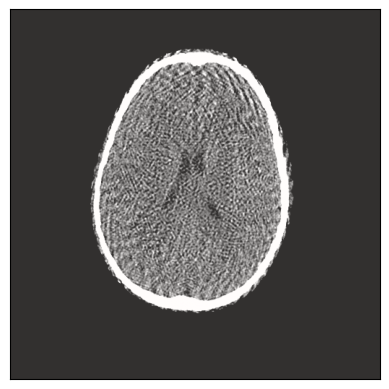

In [14]:
from utils import ctshow
import matplotlib.pyplot as plt
f, ax = plt.subplots()
idx = len(imgs) // 2
ctshow(imgs[idx], 'brain', fig=f, ax=ax)
ax.imshow(mask[idx], cmap='Reds', alpha=0.2)

In [15]:
from utils import scrollview
scrollview(imgs, (1000, 400))

interactive(children=(IntSlider(value=67, description='idx', max=134), Output()), _dom_classes=('widget-intera…